## 1. Data Loading

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv('deliveries.csv')
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


## 2. Data Validation

In [17]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (260920, 17)
Columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


What is the maximum number of balls bowled in a single match?

In [18]:
balls_per_match=df.groupby('match_id').size()
print(balls_per_match.head())

match_id
335982    225
335983    248
335984    219
335985    246
335986    240
dtype: int64


In [19]:
max_balls = balls_per_match.max()
print("Max balls in a match:", max_balls)

Max balls in a match: 269


## 3. Balls per Match Analysis

Has any match gone significantly over the standard 120 balls per innings?

In [20]:
extra_matches = balls_per_match[balls_per_match > 240]

print("Matches with more than 240 balls:")
print(extra_matches)

Matches with more than 240 balls:
match_id
335983     248
335985     246
335987     241
335989     255
335990     248
          ... 
1426305    259
1426306    253
1426307    247
1426310    241
1426311    251
Length: 707, dtype: int64


In [26]:
extra_matches.max()

269

### Observation on Ball Count

- The maximum number of deliveries in a match is 269.
- Many matches exceed the expected 240 deliveries.
- This is not an anomaly, as extra deliveries occur due to wides and no-balls.
- Therefore, higher ball counts are expected in real match scenarios.

## 4. Dismissal Analysis

Identify the types of dismissals present in the dismissal_kind column.

In [21]:
dismissals = df['dismissal_kind'].dropna()

print("Dismissal types:")
print(dismissals.unique())

Dismissal types:
['caught' 'bowled' 'run out' 'lbw' 'retired hurt' 'stumped'
 'caught and bowled' 'hit wicket' 'obstructing the field' 'retired out']


In [22]:
dismissal_counts = dismissals.value_counts()

print(dismissal_counts)

dismissal_kind
caught                   8063
bowled                   2212
run out                  1114
lbw                       800
caught and bowled         367
stumped                   358
retired hurt               15
hit wicket                 15
obstructing the field       3
retired out                 3
Name: count, dtype: int64


In [29]:
print("\nTop 3 dismissal types:")
print(dismissal_counts.head(3))


Top 3 dismissal types:
dismissal_kind
caught     8063
bowled     2212
run out    1114
Name: count, dtype: int64


## 5. Visualization

Create a pie chart or bar plot showing the overall distribution of the different dismissal types (bowled, caught, run out, lbw, etc.).

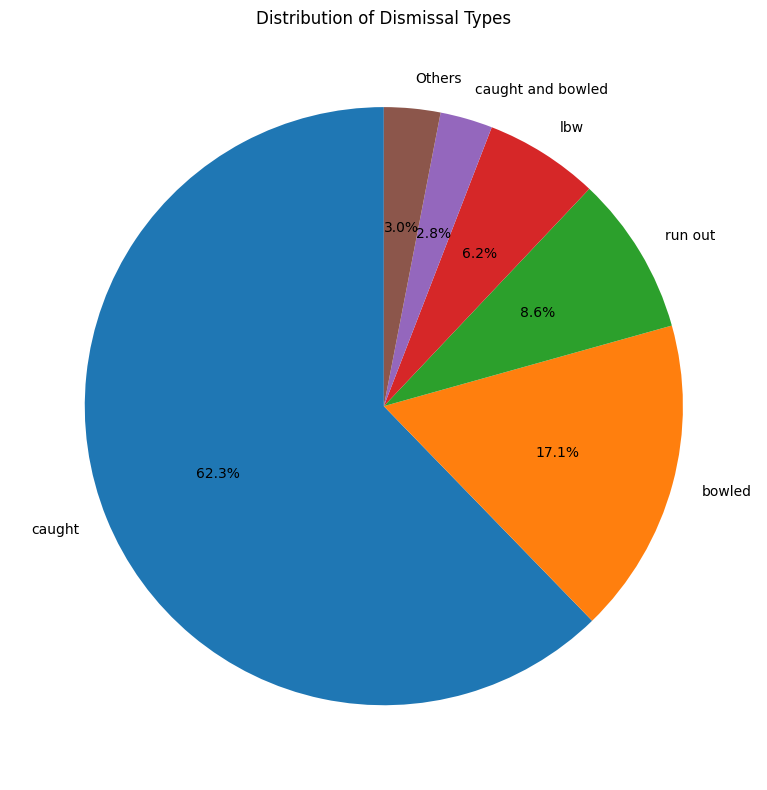

In [27]:
# Keep top 5, group rest as 'Others'(large data)
top = dismissal_counts.head(5)
others = pd.Series({'Others': dismissal_counts[5:].sum()})

final_counts = pd.concat([top, others])

plt.figure(figsize=(8,8))
final_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Dismissal Types")
plt.ylabel('')
plt.tight_layout()
plt.show()

Most common dismissal

In [28]:
print("Most common dismissal:", dismissal_counts.idxmax())

Most common dismissal: caught


## Insight Summary

- The dataset contains ball-by-ball data, so it is much larger than the matches dataset.
- The maximum number of deliveries in a match is 269.
- Around 707 matches have more than 240 deliveries, which is expected due to extras like wides and no-balls.
- Different types of dismissals are present such as caught, bowled, run out, and lbw.
- The most common dismissal type is **caught**, followed by bowled and run out.
- The chart shows that caught dismissals occur the most.